2.802179804302237
Data downloaded successfully!


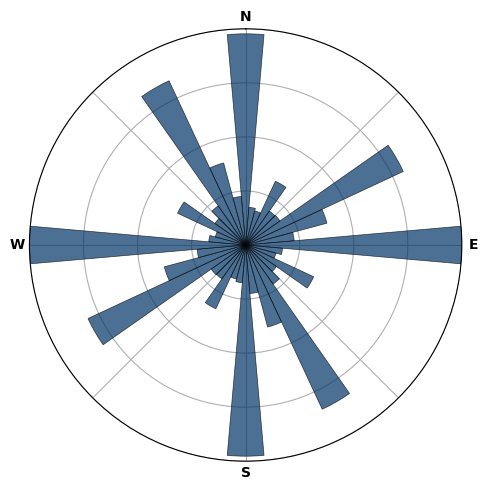

In [345]:
import osmnx as ox
from metrics.buildings import calculate_building_metrics, calculate_building_wall_entropy
from metrics.intersections import calculate_intersection_complexity, calculate_intersection_density
from metrics.streets import calculate_dead_end_density

ox.settings.use_cache = True

# place_name = "Manhattan, New York, USA"
# place_name = "Melbourne, Australia"
place_name = "Detroit, Michigan, USA"
# place_name = "New Orleans, Louisiana, USA"
# place_name = "Philadelphia, Pennsylvania, USA"
# place_name = "Vancouver, Canada"
# place_name = "Mexico City, Mexico"
# place_name = "Buenos Aires, Argentina"
# place_name = "San Francisco, USA"
# place_name = "Kyiv, Ukraine"

print("Downloading data...")
# graph = ox.graph_from_place(place_name, network_type="all", simplify=False)
# graph = ox.graph_from_place(place_name, network_type="drive", simplify=False)
graph = ox.graph_from_place(place_name, network_type="drive", simplify=True)#, retain_all=True)

ox.bearing.add_edge_bearings(graph)
# convet to undirected graph
G = ox.convert.to_undirected(graph)
test = ox.bearing.orientation_entropy(G, num_bins=36, min_length=0, weight=None)
print(test)
# plot orientation
ox.plot.plot_orientation(G, num_bins=36, min_length=0, weight=None, figsize=(5, 5), area=True, color='#003366', edgecolor='k', linewidth=0.5, alpha=0.7, title=None, title_y=1.05, title_font=None)
print("Data downloaded successfully!")
# nodes, edges = ox.graph_to_gdfs(graph)
# utm_crs = ox.projection.project_graph(graph).graph["crs"]
# edges = edges.to_crs(utm_crs)
# nodes = nodes.to_crs(utm_crs)


In [ ]:
from math import radians, cos
import osmnx as ox
from geographiclib.geodesic import Geodesic

ox.stats.circuity_avg

ox.stats.street_length_total

def calculate_min_zoom_level(place_name):
    # from OSM wiki on Zoom_levels - https://wiki.openstreetmap.org/wiki/Zoom_levels
    geocode_result = ox.geocode_to_gdf(place_name)
    if geocode_result is not None and not geocode_result.empty:
        lon_min, lat_min, lon_max, lat_max = geocode_result.total_bounds
        lond = abs(lon_max - lon_min)
        lon_level = 0
        for level in range(21, 0, -1):
            s = 360 / 2**level
            if s > lond:
                # return level
                lon_level = level
                break
        geod = Geodesic.WGS84
        g = geod.Inverse(lat_min, lon_min, lat_max, lon_min)
        latd = g["s12"]  # N-S distance in meters
        lat_level = 0
        for level in range(21, 0, -1):
            s = 40075016.686 * cos(radians(lat_max)) / (2**level)
            if s > latd:
                lat_level = level
                break
        print(lon_level, lat_level)
        return min(lon_level, lat_level)
    else:
        raise ValueError("Place not found.")

cities = [
    "Sermersooq, Greenland",
    "Perth, Australia",
    "Honalulu, Hawaii",
    "Tokyo, Japan",
    "Nepal, Nepal",
    "Shanghai, China",
    "Hangzhou, China",
    "London, United Kingdom",
    "Kyiv, Ukraine",
    "Lviv, Ukraine",
    "Drohobych, Ukraine",
    "Vynnyky, Ukraine",
    "Halytskyi District, Lviv, Ukraine",
    "Bibrka, Ukraine",
]

for city in cities:
    print(city, calculate_min_zoom_level(city))

3 3
Sermersooq, Greenland 3
12 12
Perth, Australia 12
10 11
Honalulu, Hawaii 10
4 4
Tokyo, Japan 4
5 6
Nepal, Nepal 5
6 6
Shanghai, China 6
7 7
Hangzhou, China 7
8 9
London, United Kingdom 8
9 9
Kyiv, Ukraine 9
10 10
Lviv, Ukraine 10
11 11
Drohobych, Ukraine 11
12 12
Vynnyky, Ukraine 12
12 12
Halytskyi District, Lviv, Ukraine 12
13 13
Bibrka, Ukraine 13


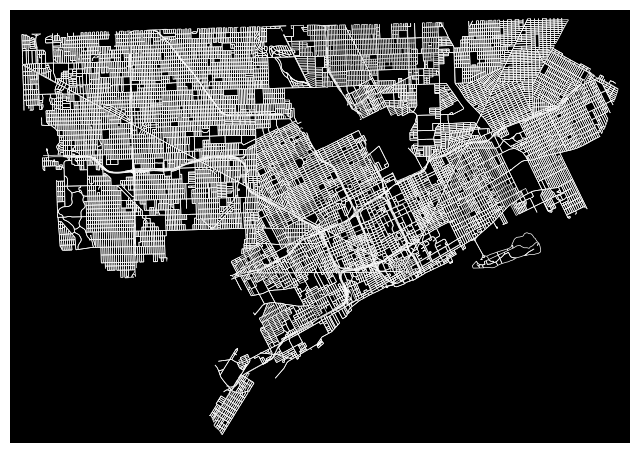

Removed 1254 unuseful nodes


In [261]:
from matplotlib import pyplot as plt
modified_graph = graph.copy()

# going through all the edges and removing the ones that are not dead-ends or connected to intersections directly.
to_remove = []
for node in modified_graph.nodes:
    successors = list(modified_graph.successors(node))
    predecessors = list(modified_graph.predecessors(node))
    if len(successors) == 1 and len(predecessors) == 1:
        to_remove.append(node)
modified_graph.remove_nodes_from(to_remove)

nnodes, nedges = ox.graph_to_gdfs(modified_graph)

utm_crs = ox.projection.project_graph(modified_graph).graph["crs"]
# nedges = nedges.to_crs(utm_crs)
# nnodes = nnodes.to_crs(utm_crs)

fig, ax = ox.plot_graph(modified_graph, node_size=0, edge_linewidth=0.5, edge_color="w", bgcolor="k")
plt.show()

print(f"Removed {len(to_remove)} unuseful nodes")

In [262]:
import geographiclib.geodesic
from matplotlib import pyplot as plt
import numpy as np
from math import ceil
import geographiclib


def calculate_street_orientation_entropy(edges):
    cbins = [  # I'll change it in the future
        (355, 5),
        (5, 15),
        (15, 25),
        (25, 35),
        (35, 45),
        (45, 55),
        (55, 65),
        (65, 75),
        (75, 85),
        (85, 95),
        (95, 105),
        (105, 115),
        (115, 125),
        (125, 135),
        (135, 145),
        (145, 155),
        (155, 165),
        (165, 175),
        (175, 185),
        (185, 195),
        (195, 205),
        (205, 215),
        (215, 225),
        (225, 235),
        (235, 245),
        (245, 255),
        (255, 265),
        (265, 275),
        (275, 285),
        (285, 295),
        (295, 305),
        (305, 315),
        (315, 325),
        (325, 335),
        (335, 345),
        (345, 355),
    ]
    print(len(cbins))

    # edges["angle"] = edges.geometry.apply(
    #     lambda geom: int(np.arctan2(
    #         geom.coords[-1][1] - geom.coords[0][1],
    #         geom.coords[-1][0] - geom.coords[0][0],
    #     )
    #     * 180 / np.pi + 0) % 360 # + 2.5 was found empirically to match the original results
    # )
    # calculating geographically accurate angles using geographiclib
    geod = geographiclib.geodesic.Geodesic.WGS84
    edges["angle"] = edges.geometry.apply(
        lambda geom: #ceil(
            geod.Inverse(
                geom.coords[0][1],
                geom.coords[0][0],
                geom.coords[-1][1],
                geom.coords[-1][0],
            )["azi1"]
            # + 2.5
        # )
        % 360
    )

    # printing the histogram of street orientations
    # plt.hist(edges["angle"], bins=36, range=(0, 360))
    # plt.title("Street Orientation Distribution")
    # plt.xlabel("Angle (degrees)")
    # plt.ylabel("Count")
    # plt.xticks(np.arange(0, 361, 20))
    # plt.show()

    # counts, _ = np.histogram(edges["angle"], bins=36, range=(0, 360))
    counts = np.zeros(36)
    for i, (start, end) in enumerate(cbins):
        cnt = edges[(edges["angle"] > start) & (edges["angle"] <= end)].shape[0]
        if i == 0:
            cnt = edges[(edges["angle"] > start) | (edges["angle"] <= end)].shape[0]
        # print(f"({start}, {end}) + ({start + 180}, {(end + 180)%360}) = {cnt}")
        counts[i] = cnt
    for i in range(18):
        counts[i] += counts[i + 18]
        counts[i + 18] = counts[i]
        # print(f"{i} = {cbins[i]} + {cbins[i + 18]} = {counts[i]}")

    # print(counts)

    proportions = counts / counts.sum()
    counts = counts / counts.sum()
    # proportions = proportions[proportions > 0]  # should not be necessary
    entropy = -np.sum(proportions * np.log(proportions))
    return entropy, counts


def plot_polar_entropy(angle_counts):
    bin_centers = np.linspace(0, 360, 36, endpoint=False)
    theta = np.radians(bin_centers)  # Convert to radians
    fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(6, 6))
    ax.bar(theta, angle_counts, width=np.radians(10), edgecolor="black", alpha=0.7)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title("Street Orientation Distribution (Entropy)")
    ax.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "45°", "E", "135°", "S", "225°", "W", "315°"])
    plt.show()

36
Phi, Ho: 0.615, 2.750


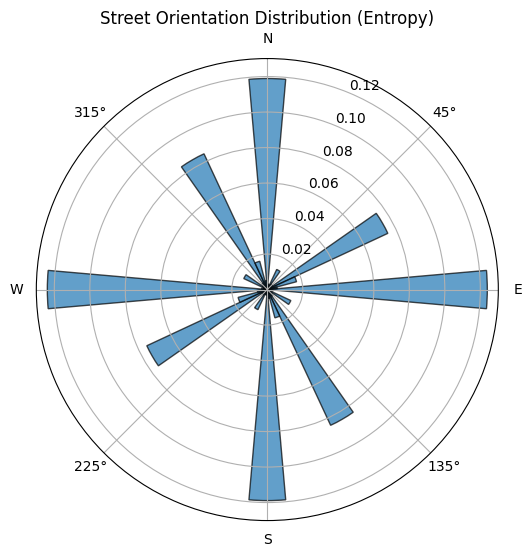

In [263]:
street_entropy, angle_counts = calculate_street_orientation_entropy(nedges)
phi = 1 - (((street_entropy-1.386)/(3.584-1.386))**2)
print(f"Phi, Ho: {phi:.3f}, {street_entropy:.3f}")
plot_polar_entropy(angle_counts)